### Lucas Kanade Optical Flow

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
cap = cv2.VideoCapture("data/videos/cycle.mp4")

In [3]:
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter('sparse_output.mp4', cv2.VideoWriter_fourcc(*'MP4V'), 20, (width, height))

In [5]:
# params for ShiTomasi corner detection
numCorners = 100
feature_params = dict(maxCorners = numCorners, qualityLevel = 0.3, minDistance = 7, blockSize = 7)

In [6]:
# Parameters for lucas kanade optical flow
lk_params = dict(winSize = (15, 15), maxLevel = 2, 
                 criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

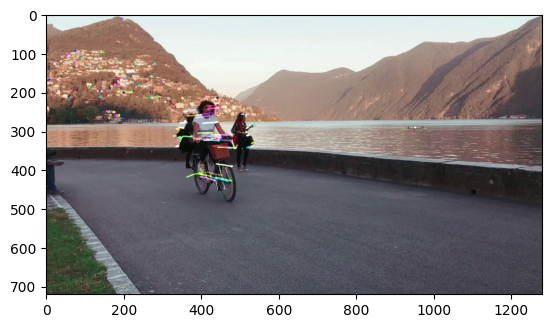

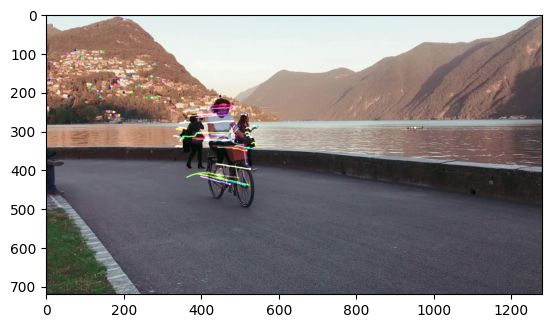

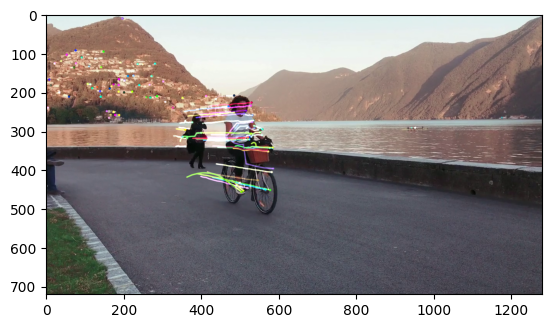

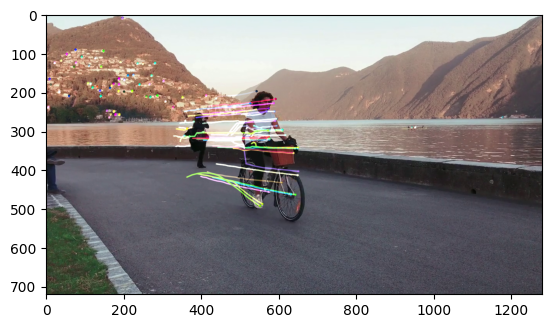

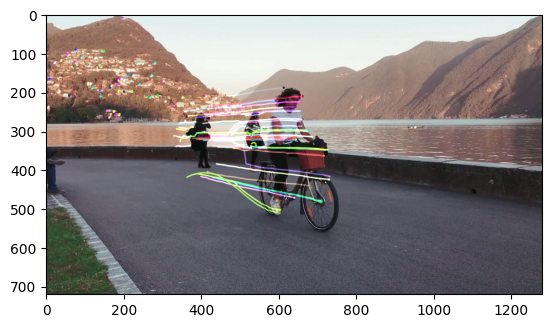

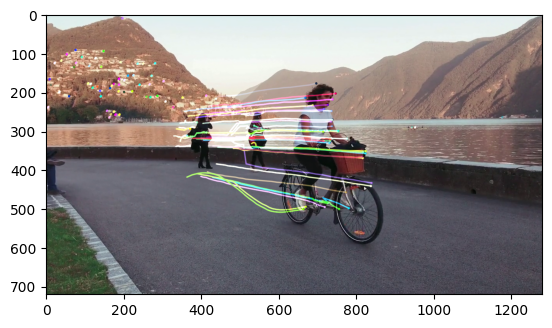

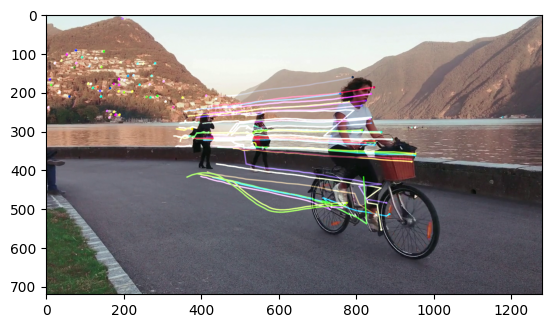

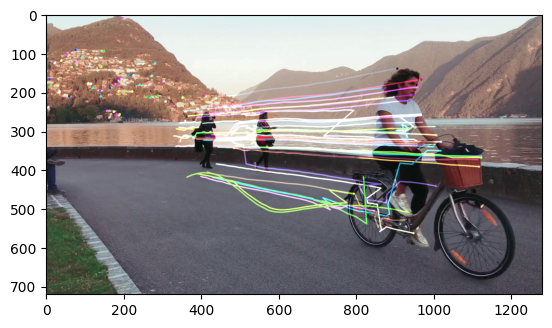

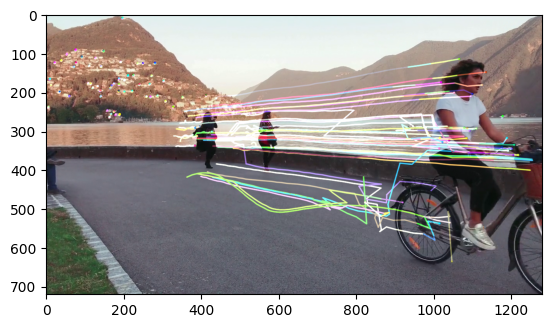

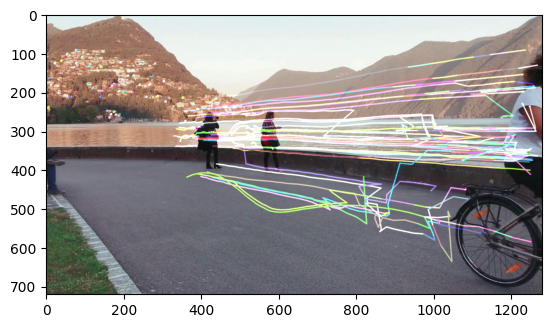

In [7]:
color = np.random.randint(0, 255, (numCorners, 3))

ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
old_points = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

mask = np.zeros_like(old_frame)
count = 0

while(1):
    ret, frame = cap.read()
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    count += 1

    # calculate new optical flow
    new_points, status, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, old_points, None, **lk_params)

    # Select good points
    good_new = new_points[status == 1]
    good_old = old_points[status == 1]

    # draw the tracks
    for i, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = new.ravel()
        c, d = old.ravel()
        cv2.line(img = mask, pt1 = (int(a), int(b)), pt2 = (int(c), int(d)), color=color[i].tolist(), thickness=2, lineType=cv2.LINE_AA)
        cv2.circle(frame, (int(a), int(b)), 3, color[i].tolist(), -1)

    # display every 5th frame
    display_frame = cv2.add(frame, mask)
    out.write(display_frame)
    if count%5 == 0:
        plt.imshow(display_frame[...,::-1])
        plt.show()
    if count > 50:
        break

    # update previous frame and previous points
    old_gray = frame_gray.copy()
    old_points = good_new.reshape(-1, 1, 2)

In [8]:
cap.release()
out.release()

### Application: Video Stabalization

In [42]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [43]:
cap = cv2.VideoCapture('data/videos/video.mp4')
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

n_frames, w, h, fps

(1362, 720, 480, 29)

In [44]:
out = cv2.VideoWriter('video_out1.avi', cv2.VideoWriter_fourcc('M','J','P','G'), fps, (w*2, h))

In [45]:
_, prev = cap.read()
prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

In [46]:
transforms = np.zeros((n_frames-1, 3), np.float32)

In [47]:
SMOOTHING_RADIUS = 100

In [48]:
for i in range(n_frames-2):
    # detect good feature points from previous frame
    prev_pts = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01, minDistance=30, blockSize=3)

    success, curr = cap.read()
    if not success:
        break

    curr_gray = cv2.cvtColor(curr, cv2.COLOR_BGR2GRAY)

    # calculate optical flow
    curr_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None)

    assert prev_pts.shape == curr_pts.shape

    idx = np.where(status==1)[0]
    prev_pts = prev_pts[idx]
    curr_pts = curr_pts[idx]

    m = cv2.estimateAffinePartial2D(prev_pts, curr_pts)
    # Extract translation
    dx = m[0][0,2]
    dy = m[0][1,2]

    da = np.arctan2(m[0][1,0], m[0][0,0])

    # store transformations
    transforms[i] = [dx, dy, da]

    prev_gray = curr_gray

    print("Frame: " + str(i) + "/" + str(n_frames) + " - Tracked points : " + str(len(prev_pts)))

Frame: 0/1362 - Tracked points : 106
Frame: 1/1362 - Tracked points : 108
Frame: 2/1362 - Tracked points : 104
Frame: 3/1362 - Tracked points : 106
Frame: 4/1362 - Tracked points : 107
Frame: 5/1362 - Tracked points : 107
Frame: 6/1362 - Tracked points : 110
Frame: 7/1362 - Tracked points : 110
Frame: 8/1362 - Tracked points : 102
Frame: 9/1362 - Tracked points : 109
Frame: 10/1362 - Tracked points : 104
Frame: 11/1362 - Tracked points : 107
Frame: 12/1362 - Tracked points : 109
Frame: 13/1362 - Tracked points : 108
Frame: 14/1362 - Tracked points : 104
Frame: 15/1362 - Tracked points : 109
Frame: 16/1362 - Tracked points : 103
Frame: 17/1362 - Tracked points : 106
Frame: 18/1362 - Tracked points : 104
Frame: 19/1362 - Tracked points : 110
Frame: 20/1362 - Tracked points : 102
Frame: 21/1362 - Tracked points : 104
Frame: 22/1362 - Tracked points : 103
Frame: 23/1362 - Tracked points : 103
Frame: 24/1362 - Tracked points : 102
Frame: 25/1362 - Tracked points : 104
Frame: 26/1362 - Track

In [49]:
trajectory = np.cumsum(transforms, axis=0)

def movingAverage(curve, radius):
    window_size = 2*radius+1
    # Define the filter
    f = np.ones(window_size)/window_size
    # Add padding to the boundaries
    curve_pad = np.pad(curve, (radius, radius), 'edge')
    # Apply convolution
    curve_smoothed = np.convolve(curve_pad, f, mode='same')
    # Remove padding
    curve_smoothed = curve_smoothed[radius: -radius]
    # return smoothed curve
    return curve_smoothed

In [50]:
def smooth(trajectory):
    smoothed_trajectory = np.copy(trajectory)

    # filter x, y and angle curves
    for i in range(3):
        smoothed_trajectory[:,i] = movingAverage(trajectory[:,i], radius=SMOOTHING_RADIUS)

    return smoothed_trajectory

In [51]:
# Compute trajectory using cumulative sum of transformations
trajectory = np.cumsum(transforms, axis=0)

In [52]:
smoothed_trajectory = smooth(trajectory)

In [53]:
# Calculate difference in smoothed_trajectory and trajectory
difference = smoothed_trajectory - trajectory
  
# Calculate newer transformation array
transforms_smooth = transforms + difference

In [54]:
def fixBorder(frame):
  s = frame.shape
  # Scale the image 4% without moving the center
  T = cv2.getRotationMatrix2D((s[1]/2, s[0]/2), 0, 1.04)
  frame = cv2.warpAffine(frame, T, (s[1], s[0]))
  return frame

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

True

In [55]:
for i in range(n_frames-2):
    # Read next frame
    success, frame = cap.read() 
    if not success:
        break

    # Extract transformations from the new transformation array
    dx = transforms_smooth[i,0]
    dy = transforms_smooth[i,1]
    da = transforms_smooth[i,2]

    # Reconstruct transformation matrix accordingly to new values
    m = np.zeros((2,3), np.float32)
    m[0,0] = np.cos(da)
    m[0,1] = -np.sin(da)
    m[1,0] = np.sin(da)
    m[1,1] = np.cos(da)
    m[0,2] = dx
    m[1,2] = dy

    # Apply affine wrapping to the given frame
    frame_stabilized = cv2.warpAffine(frame, m, (w,h))

    # Fix border artifacts
    frame_stabilized = fixBorder(frame_stabilized) 

    # Write the frame to the file
    frame_out = cv2.hconcat([frame, frame_stabilized])

    # If the image is too big, resize it.
    if(frame_out.shape[1] > 1920): 
        frame_out = cv2.resize(frame_out, (w,h))
    #cv2.imshow("Frame",frame_out)
    #cv2.waitKey(0)

    out.write(frame_out)

In [56]:
cv2.destroyAllWindows()
out.release()